---
pinned_commit: 1dd5b3e6c59bdd1d12bb656c5de0a29a512863d8
purpose: stage_2_dense_timing_oracle_vs_predicted_single_audio
---

# Stage 2 Dense Timing: Oracle Redline vs Predicted Grid

Randomly select one unique audio from `mania-dataset`, choose one beatmap for that audio, and compare:

- oracle grid from the beatmap's osu red timing points
- predicted grid from Stage 2 `BeatThisTimingProvider -> GridFitter`
- both grids rendered through Stage 2 `dense_timing_v2` only


critical question: oracle-trained mapper 能否 zero-shot transfer 到 predicted dense timing？

In [442]:
from __future__ import annotations

from pathlib import Path
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def find_repo_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else Path(start).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "requirements.txt").exists() and (candidate / "train").exists():
            return candidate
    raise FileNotFoundError("could not find repo root")


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from train.stage_2.osu_core.timing import require_red_timing_points  # noqa: E402
from train.stage_2.timing.diagnostics.compare_to_oracle import (  # noqa: E402
    compare_timing_grids,
    oracle_grid_from_red_timing_points,
)
from train.stage_2.timing.grid_fitting import GridFitter, GridFitterConfig  # noqa: E402
from train.stage_2.timing.providers.beatthis import (  # noqa: E402
    DEFAULT_BEATTHIS_CHECKPOINT,
    DEFAULT_BEATTHIS_DEVICE,
    BeatThisTimingProvider,
)
from train.stage_2.timing.rendering.dense_timing_v2 import (  # noqa: E402
    DENSE_TIMING_V2_CHANNELS,
    active_timing_arrays,
    dense_timing_v2_frame_times,
    render_dense_timing_v2,
)

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 120)


In [443]:
DATASET_ROOT = REPO_ROOT / "mania-dataset"
INDEX_PATH = REPO_ROOT / "train/artifacts/indexes/beatmap_index_4k_no_timing_anomalies_2to6.parquet"

RANDOM_SEED = None  # Set an int for reproducible sampling; None picks a fresh seed each run.
RESOLVED_RANDOM_SEED = int(
    np.random.default_rng().integers(0, np.iinfo(np.uint32).max)
    if RANDOM_SEED is None
    else RANDOM_SEED
)

# Optional overrides. Keep both as None for a random unique-audio sample.
SAMPLE_AUDIO_KEY = None  # example: ("0", "1000065/audio.mp3")
SAMPLE_BEATMAP_PATH = None  # example: "1000065/Billx - Punishment ... [4K Equalizer].osu"

BEATTHIS_CHECKPOINT = DEFAULT_BEATTHIS_CHECKPOINT
BEATTHIS_DEVICE = DEFAULT_BEATTHIS_DEVICE
BEATTHIS_FLOAT16 = False
DOUBLE_TEMPO_SCORE_RATIO_THRESHOLD = None

PLOT_START_S = 0.0
PLOT_DURATION_S = 60.0
MAX_CHANGE_LINES = 80

print("repo:", REPO_ROOT)
print("dense_timing_v2 channels:", list(DENSE_TIMING_V2_CHANNELS))
print("random_seed:", RESOLVED_RANDOM_SEED)


repo: /Users/l/projects/Mapperatorinator
dense_timing_v2 channels: ['beat_pulse', 'phase_sin', 'phase_cos', 'local_bpm']
random_seed: 3075684551


In [444]:
def select_sample_row(index_df: pd.DataFrame) -> pd.Series:
    if SAMPLE_BEATMAP_PATH is not None:
        mask = index_df["beatmap_path"].astype(str) == str(SAMPLE_BEATMAP_PATH)
        matches = index_df.loc[mask]
        if matches.empty:
            raise ValueError(f"SAMPLE_BEATMAP_PATH not found in index: {SAMPLE_BEATMAP_PATH}")
        return matches.iloc[0]

    if SAMPLE_AUDIO_KEY is not None:
        shard, audio_rel_path = SAMPLE_AUDIO_KEY
        mask = (index_df["shard"].astype(str) == str(shard)) & (index_df["audio_path"].astype(str) == str(audio_rel_path))
        audio_rows = index_df.loc[mask]
        if audio_rows.empty:
            raise ValueError(f"SAMPLE_AUDIO_KEY not found in index: {SAMPLE_AUDIO_KEY}")
        return audio_rows.sample(n=1, random_state=RESOLVED_RANDOM_SEED + 1).iloc[0]

    unique_audio = index_df.drop_duplicates(["shard", "audio_path"])
    sampled_audio = unique_audio.sample(n=1, random_state=RESOLVED_RANDOM_SEED).iloc[0]
    mask = (
        (index_df["shard"].astype(str) == str(sampled_audio["shard"]))
        & (index_df["audio_path"].astype(str) == str(sampled_audio["audio_path"]))
    )
    audio_rows = index_df.loc[mask]
    return audio_rows.sample(n=1, random_state=RESOLVED_RANDOM_SEED + 1).iloc[0]


index_df = pd.read_parquet(INDEX_PATH)
sample_row = select_sample_row(index_df)

audio_path = DATASET_ROOT / str(sample_row["shard"]) / str(sample_row["audio_path"])
beatmap_path = DATASET_ROOT / str(sample_row["shard"]) / str(sample_row["beatmap_path"])

if not audio_path.is_file():
    raise FileNotFoundError(audio_path)
if not beatmap_path.is_file():
    raise FileNotFoundError(beatmap_path)

selected_columns = [
    "shard",
    "beatmap_set_id",
    "beatmap_id",
    "artist",
    "title",
    "creator",
    "version",
    "difficulty",
    "audio_path",
    "beatmap_path",
]
display(sample_row[selected_columns].to_frame("selected"))
print("audio_path:", audio_path)
print("beatmap_path:", beatmap_path)


,selected
shard,0
beatmap_set_id,474257
beatmap_id,1015327
artist,Various Artists
title,Endurance/Accuracy Training [Chords]
creator,Staravia
version,[190bpm] X Gon Give It To Ya
difficulty,4.32
audio_path,474257/xgonna.mp3
beatmap_path,474257/Various Artists - EnduranceAccuracy Tra...


audio_path: /Users/l/projects/Mapperatorinator/mania-dataset/0/474257/xgonna.mp3
beatmap_path: /Users/l/projects/Mapperatorinator/mania-dataset/0/474257/Various Artists - EnduranceAccuracy Training [Chords] (Staravia) [[190bpm] X Gon Give It To Ya].osu


In [445]:
red_timing_points = require_red_timing_points(beatmap_path)
oracle_grid = oracle_grid_from_red_timing_points(red_timing_points)

provider = BeatThisTimingProvider(
    checkpoint_path=BEATTHIS_CHECKPOINT,
    device=BEATTHIS_DEVICE,
    float16=BEATTHIS_FLOAT16,
)
prediction_start_seconds = time.perf_counter()
prediction = provider.predict_file(audio_path)
prediction_seconds = time.perf_counter() - prediction_start_seconds

if DOUBLE_TEMPO_SCORE_RATIO_THRESHOLD is None:
    fitter_config = GridFitterConfig()
else:
    fitter_config = GridFitterConfig(
        double_tempo_score_ratio_threshold=DOUBLE_TEMPO_SCORE_RATIO_THRESHOLD,
    )

fit_start_seconds = time.perf_counter()
fit_result = GridFitter(fitter_config).fit(prediction)
fit_seconds = time.perf_counter() - fit_start_seconds
predicted_grid = fit_result.grid

comparison = compare_timing_grids(
    predicted_grid,
    oracle_grid,
    frame_count=prediction.frame_count,
)
audio_duration_s = prediction.frame_count / prediction.frame_rate_hz
audio_duration_ms = audio_duration_s * 1000.0

print(f"BeatThis prediction_seconds: {prediction_seconds:.3f}")
print(f"GridFitter fit_seconds: {fit_seconds:.3f}")
print(f"frame_count: {prediction.frame_count} at {prediction.frame_rate_hz:g} Hz")
print(f"audio_duration_s: {audio_duration_s:.3f}")
print(f"oracle segment_count: {len(oracle_grid.segments)}")
print(f"predicted segment_count: {len(predicted_grid.segments)}")


BeatThis prediction_seconds: 2.596
GridFitter fit_seconds: 0.616
frame_count: 11178 at 50 Hz
audio_duration_s: 223.560
oracle segment_count: 2
predicted segment_count: 2


In [446]:
def segment_dataframe(grid, label: str, duration_ms: float) -> pd.DataFrame:
    segments = list(grid.segments)
    records = []
    for index, segment in enumerate(segments):
        end_ms = segments[index + 1].offset_ms if index + 1 < len(segments) else duration_ms
        records.append(
            {
                "grid": label,
                "segment": index + 1,
                "start_ms": segment.offset_ms,
                "start_s": segment.offset_ms / 1000.0,
                "end_ms": end_ms,
                "end_s": end_ms / 1000.0,
                "bpm": segment.local_bpm,
                "beat_length_ms": segment.beat_length_ms,
                "meter": segment.meter,
            }
        )
    return pd.DataFrame.from_records(records)


oracle_segments_df = segment_dataframe(oracle_grid, "oracle_redline", audio_duration_ms)
predicted_segments_df = segment_dataframe(predicted_grid, "stage2_predicted", audio_duration_ms)

fit_summary = {
    "fit_score": fit_result.score,
    "prediction_seconds": prediction_seconds,
    "fit_seconds": fit_seconds,
    "candidate_count": fit_result.diagnostics.candidate_count,
    "alias_candidate_count": fit_result.diagnostics.alias_candidate_count,
    "raw_selected_bpm": fit_result.diagnostics.raw_selected_bpm,
    "tempo_multiplier": fit_result.diagnostics.tempo_multiplier,
}

comparison_summary = pd.DataFrame([comparison.__dict__]).T.rename(columns={0: "value"})
fit_summary_df = pd.DataFrame([fit_summary]).T.rename(columns={0: "value"})

print("Oracle redline timing grid: when BPM what")
display(oracle_segments_df)

print("Predicted Stage 2 timing grid: when BPM what")
display(predicted_segments_df)

print("Dense timing v2 grid comparison metrics")
display(comparison_summary)

print("Stage 2 fitter summary")
display(fit_summary_df)


Oracle redline timing grid: when BPM what


,grid,segment,start_ms,start_s,end_ms,end_s,bpm,beat_length_ms,meter
0,oracle_redline,1,258.0,0.258,27686.0,27.686,140.0,428.571429,4
1,oracle_redline,2,27686.0,27.686,223560.0,223.560,190.0,315.789474,4


Predicted Stage 2 timing grid: when BPM what


,grid,segment,start_ms,start_s,end_ms,end_s,bpm,beat_length_ms,meter
0,stage2_predicted,1,280.000000,0.280000,29612.631579,29.612632,140.0,428.571429,4
1,stage2_predicted,2,29612.631579,29.612632,223560.000000,223.560000,95.0,631.578947,4


Dense timing v2 grid comparison metrics


,value
frame_count,11178.000000
beat_pulse_mae,0.137862
local_bpm_mae,82.847107
local_bpm_alias_mae,0.433888
mean_phase_error_beats,0.225588
max_phase_error_beats,0.499833
mean_phase_error_ms,71.955036
max_phase_error_ms,157.842100


Stage 2 fitter summary


,value
fit_score,0.828548
prediction_seconds,2.596303
fit_seconds,0.616014
candidate_count,1996.000000
alias_candidate_count,15.000000
raw_selected_bpm,70.000000
tempo_multiplier,2.000000


In [447]:
frame_times_ms = dense_timing_v2_frame_times(0.0, frame_count=prediction.frame_count)
frame_times_s = frame_times_ms / 1000.0

oracle_track = render_dense_timing_v2(
    oracle_grid,
    input_start_ms=0.0,
    frame_count=prediction.frame_count,
)
predicted_track = render_dense_timing_v2(
    predicted_grid,
    input_start_ms=0.0,
    frame_count=prediction.frame_count,
)

track_summary = pd.DataFrame(
    {
        "channel": list(DENSE_TIMING_V2_CHANNELS),
        "oracle_mean": oracle_track.mean(axis=0),
        "predicted_mean": predicted_track.mean(axis=0),
        "mean_abs_delta": np.abs(predicted_track - oracle_track).mean(axis=0),
    }
)
display(track_summary)


,channel,oracle_mean,predicted_mean,mean_abs_delta
0,beat_pulse,0.122560,0.067332,0.137862
1,phase_sin,-0.000300,0.000181,0.731553
2,phase_cos,0.000039,0.000017,0.739438
3,local_bpm,183.809265,100.962158,82.847107


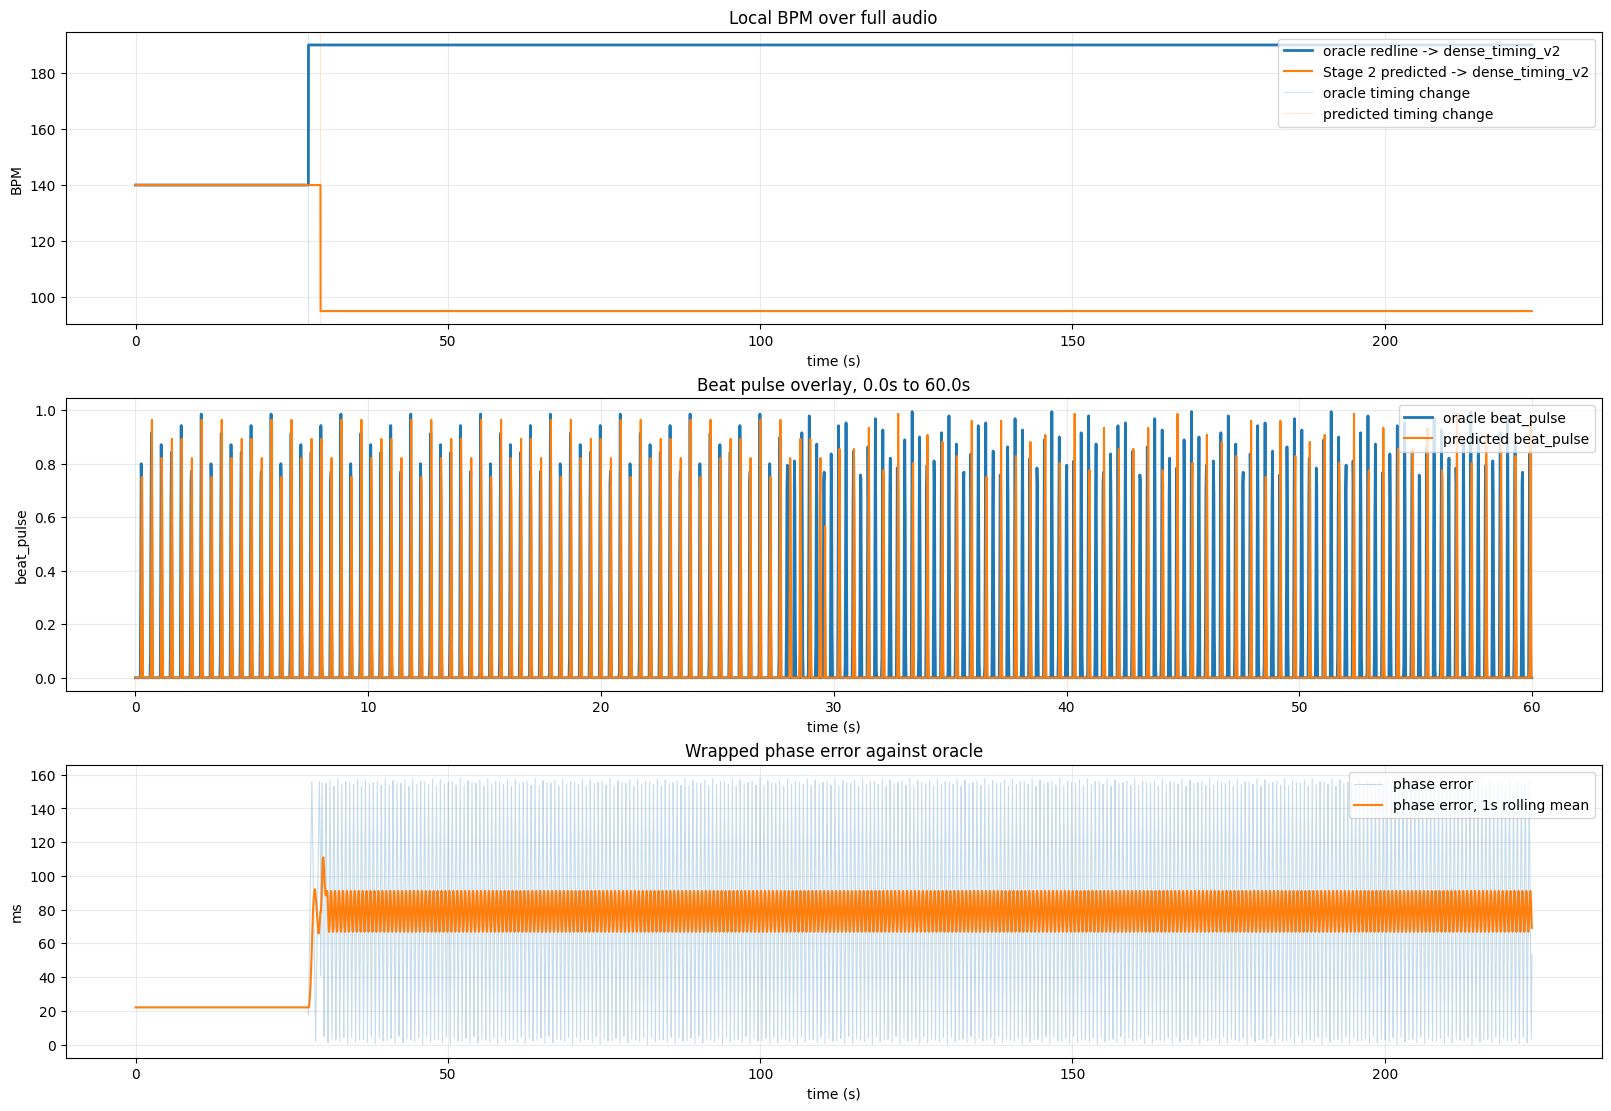

In [448]:
def phase_error_beats(predicted_track: np.ndarray, oracle_track: np.ndarray) -> np.ndarray:
    angle_delta = np.arctan2(
        predicted_track[:, 1] * oracle_track[:, 2] - predicted_track[:, 2] * oracle_track[:, 1],
        predicted_track[:, 2] * oracle_track[:, 2] + predicted_track[:, 1] * oracle_track[:, 1],
    )
    return np.abs(angle_delta) / (2.0 * np.pi)


def draw_change_lines(ax, grid, color: str, label: str) -> None:
    offsets_s = [segment.offset_ms / 1000.0 for segment in list(grid.segments)[1:]]
    for index, offset_s in enumerate(offsets_s[:MAX_CHANGE_LINES]):
        ax.axvline(
            offset_s,
            color=color,
            alpha=0.18,
            linewidth=0.8,
            label=label if index == 0 else None,
        )
    if len(offsets_s) > MAX_CHANGE_LINES:
        print(f"Skipped {len(offsets_s) - MAX_CHANGE_LINES} {label} change lines for readability")


_, oracle_beat_lengths_ms = active_timing_arrays(oracle_grid, frame_times_ms)
phase_error_ms = phase_error_beats(predicted_track, oracle_track) * oracle_beat_lengths_ms
phase_error_ms_rolling = pd.Series(phase_error_ms).rolling(window=50, min_periods=1).mean().to_numpy()

zoom_end_s = min(audio_duration_s, PLOT_START_S + PLOT_DURATION_S)
zoom_mask = (frame_times_s >= PLOT_START_S) & (frame_times_s <= zoom_end_s)

fig, axes = plt.subplots(3, 1, figsize=(16, 11), constrained_layout=True)

axes[0].plot(frame_times_s, oracle_track[:, 3], label="oracle redline -> dense_timing_v2", linewidth=2.0)
axes[0].plot(frame_times_s, predicted_track[:, 3], label="Stage 2 predicted -> dense_timing_v2", linewidth=1.5)
draw_change_lines(axes[0], oracle_grid, "tab:blue", "oracle timing change")
draw_change_lines(axes[0], predicted_grid, "tab:orange", "predicted timing change")
axes[0].set_title("Local BPM over full audio")
axes[0].set_xlabel("time (s)")
axes[0].set_ylabel("BPM")
axes[0].legend(loc="upper right")
axes[0].grid(alpha=0.25)

axes[1].plot(frame_times_s[zoom_mask], oracle_track[zoom_mask, 0], label="oracle beat_pulse", linewidth=2.0)
axes[1].plot(frame_times_s[zoom_mask], predicted_track[zoom_mask, 0], label="predicted beat_pulse", linewidth=1.5)
axes[1].set_title(f"Beat pulse overlay, {PLOT_START_S:.1f}s to {zoom_end_s:.1f}s")
axes[1].set_xlabel("time (s)")
axes[1].set_ylabel("beat_pulse")
axes[1].legend(loc="upper right")
axes[1].grid(alpha=0.25)

axes[2].plot(frame_times_s, phase_error_ms, label="phase error", linewidth=0.8, alpha=0.25)
axes[2].plot(frame_times_s, phase_error_ms_rolling, label="phase error, 1s rolling mean", linewidth=1.5)
axes[2].set_title("Wrapped phase error against oracle")
axes[2].set_xlabel("time (s)")
axes[2].set_ylabel("ms")
axes[2].legend(loc="upper right")
axes[2].grid(alpha=0.25)

plt.show()


human audit review notes:
local BPM exist < 10 should filter out this map

heuristic: if jump to double bpm/half bpm, then cancel this jump, use one of them

behaviour observed: human mapper will change redline bpm due to sv purposed. the beats are still correct but localbpm is not objective at all. Beats are reliable.
behaviour observed: 2/3 error! this is because we limit bpm to .5 resolution!
解决方案: 定义period lattice = [1,2,3,4,5,6,8,10,12]
然后generate_bpm_lattice(min, max, period_lattice)
我好像想到了更好的思路....先用现在的0.5 resolution做一次, 然后在附近正负0.25bpm可能candidate再搜索, 看是否增强解释力.